In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Projects/SDA/RideShare.csv')

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


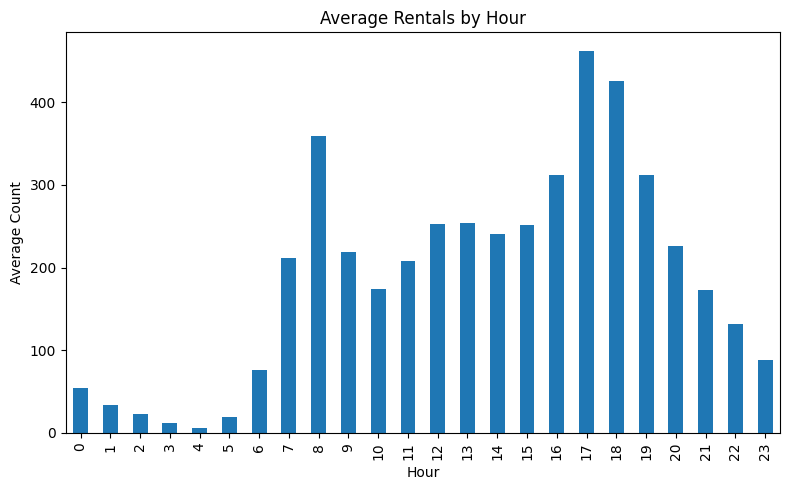

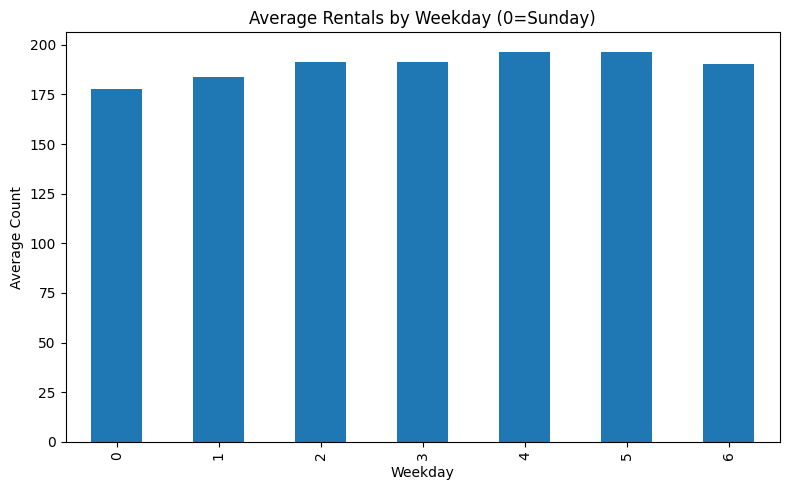

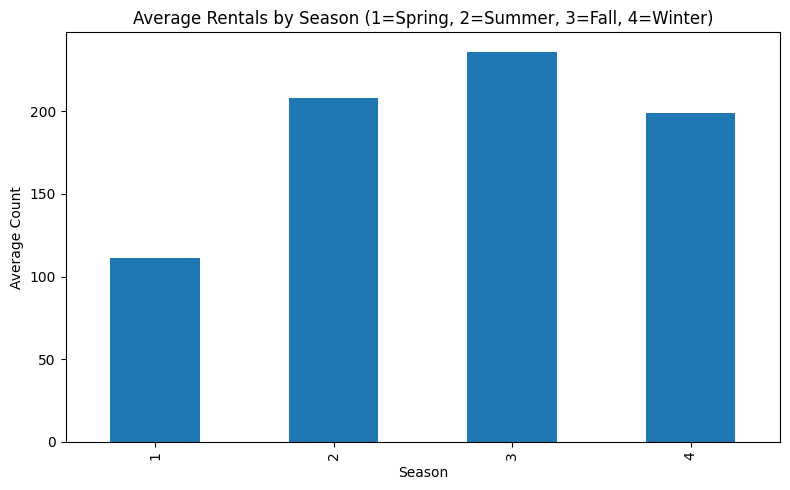

{'Total Records': 17379,
 'Columns': ['instant',
  'dteday',
  'season',
  'yr',
  'mnth',
  'hr',
  'holiday',
  'weekday',
  'workingday',
  'weathersit',
  'temp',
  'atemp',
  'hum',
  'windspeed',
  'casual',
  'registered',
  'cnt',
  'day'],
 'Missing Values': {'instant': 0,
  'dteday': 0,
  'season': 0,
  'yr': 0,
  'mnth': 0,
  'hr': 0,
  'holiday': 0,
  'weekday': 0,
  'workingday': 0,
  'weathersit': 0,
  'temp': 0,
  'atemp': 0,
  'hum': 0,
  'windspeed': 0,
  'casual': 0,
  'registered': 0,
  'cnt': 0,
  'day': 0},
 'Sample Data':    instant     dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
 0        1 2011-01-01       1   0     1   0        0        6           0   
 1        2 2011-01-01       1   0     1   1        0        6           0   
 2        3 2011-01-01       1   0     1   2        0        6           0   
 3        4 2011-01-01       1   0     1   3        0        6           0   
 4        5 2011-01-01       1   0     1   4        0        

In [ ]:
df['dteday'] = pd.to_datetime(df['dteday'])
df['day'] = df['dteday'].dt.day_name()

summary = {
    "Total Records": len(df),
    "Columns": df.columns.tolist(),
    "Missing Values": df.isnull().sum().to_dict(),
    "Sample Data": df.head(5)
}

avg_by_hour = df.groupby('hr')['cnt'].mean()

avg_by_weekday = df.groupby('weekday')['cnt'].mean()

avg_by_season = df.groupby('season')['cnt'].mean()

# Plotting
plt.figure(figsize=(8, 5))
avg_by_hour.plot(kind='bar')
plt.title("Average Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
avg_by_weekday.plot(kind='bar')
plt.title("Average Rentals by Weekday (0=Sunday)")
plt.xlabel("Weekday")
plt.ylabel("Average Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
avg_by_season.plot(kind='bar')
plt.title("Average Rentals by Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)")
plt.xlabel("Season")
plt.ylabel("Average Count")
plt.tight_layout()
plt.show()

summary


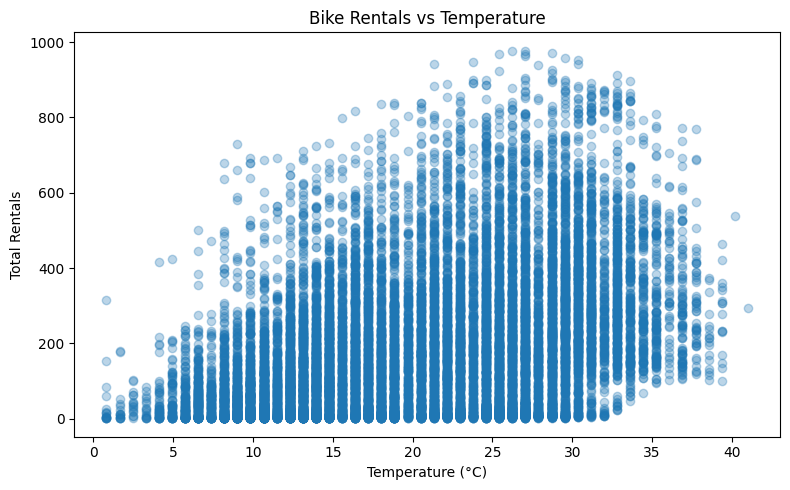

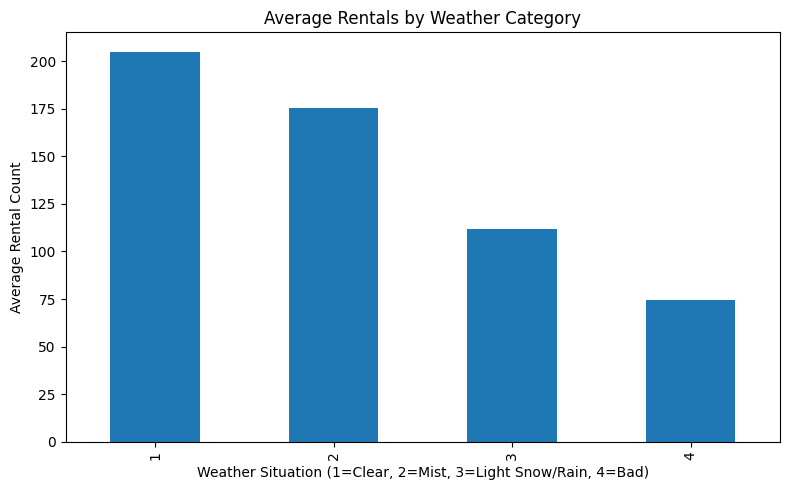

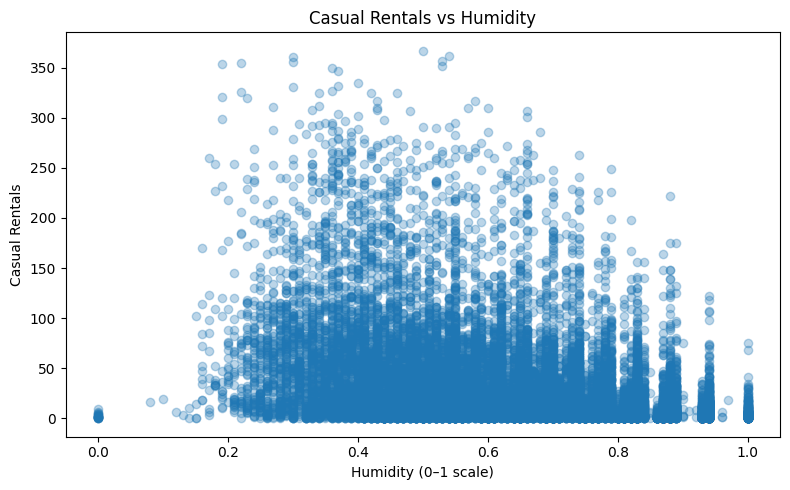

In [ ]:

df['dteday'] = pd.to_datetime(df['dteday'])

df['temp_celsius'] = df['temp'] * 41
df['atemp_celsius'] = df['atemp'] * 50

plt.figure(figsize=(8, 5))
plt.scatter(df['temp_celsius'], df['cnt'], alpha=0.3)
plt.title("Bike Rentals vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Rentals")
plt.tight_layout()
plt.show()

weather_avg = df.groupby('weathersit')['cnt'].mean()

plt.figure(figsize=(8, 5))
weather_avg.plot(kind='bar')
plt.title("Average Rentals by Weather Category")
plt.xlabel("Weather Situation (1=Clear, 2=Mist, 3=Light Snow/Rain, 4=Bad)")
plt.ylabel("Average Rental Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['hum'], df['casual'], alpha=0.3)
plt.title("Casual Rentals vs Humidity")
plt.xlabel("Humidity (0–1 scale)")
plt.ylabel("Casual Rentals")
plt.tight_layout()
plt.show()


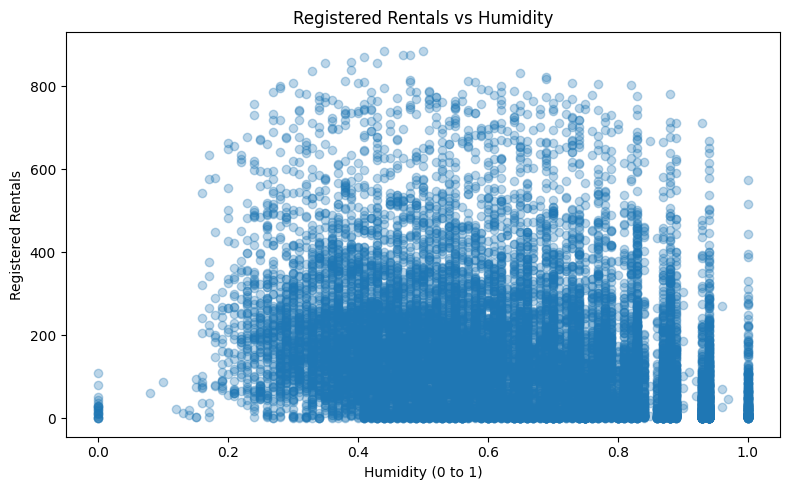

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['hum'], df['registered'], alpha=0.3)
plt.title("Registered Rentals vs Humidity")
plt.xlabel("Humidity (0 to 1)")
plt.ylabel("Registered Rentals")
plt.tight_layout()
plt.show()

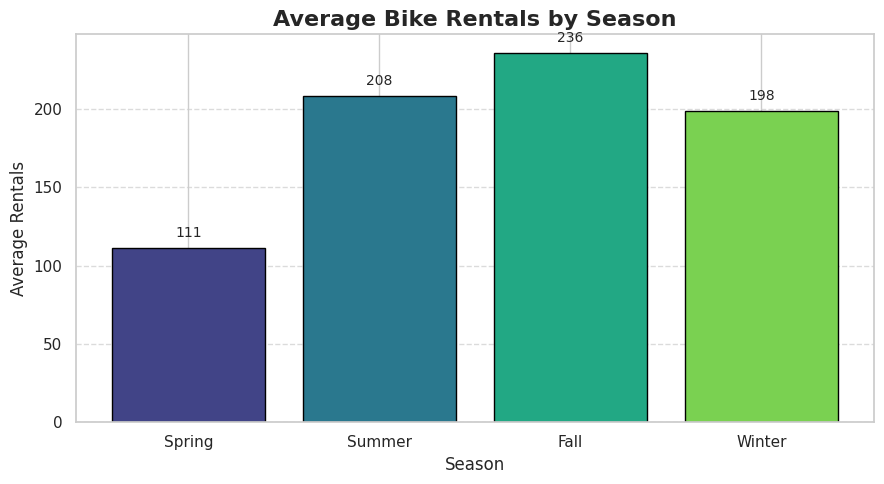

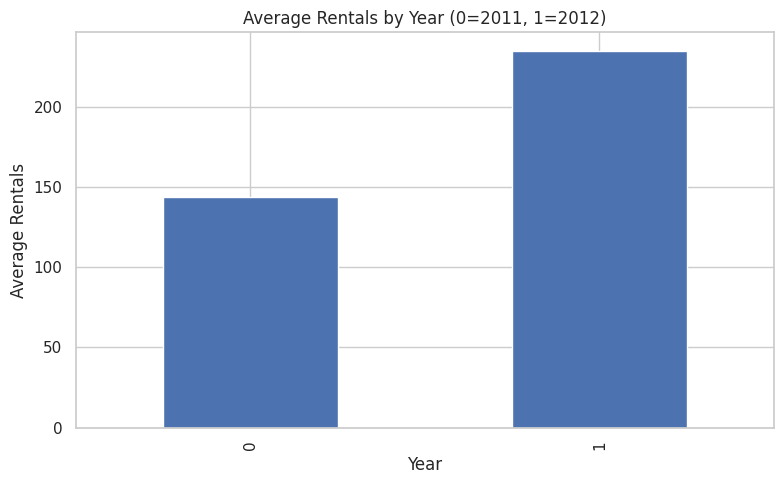

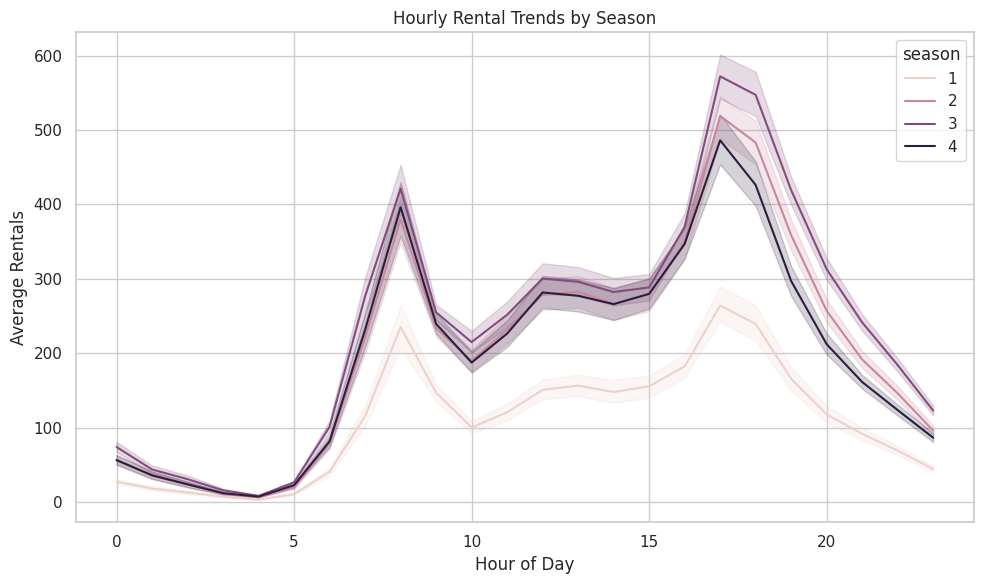

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style
sns.set(style="whitegrid")

# Prepare data
season_avg = df.groupby('season')['cnt'].mean()
season_labels = ['Spring', 'Summer', 'Fall', 'Winter']

# Plot
plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", len(season_avg))  # Nice gradient

bars = plt.bar(season_labels, season_avg.values, color=colors, edgecolor='black')

# Annotate bar values (only once)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 5, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

# Title and labels
plt.title("Average Bike Rentals by Season", fontsize=16, fontweight='bold')
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Rentals", fontsize=12)

# Grid and layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# Hypothesis 2: Rentals in 2011 vs 2012
year_avg = df.groupby('yr')['cnt'].mean()
plt.figure(figsize=(8,5))
year_avg.plot(kind='bar')
plt.title("Average Rentals by Year (0=2011, 1=2012)")
plt.xlabel("Year")
plt.ylabel("Average Rentals")
plt.tight_layout()
plt.show()

# Hypothesis 3: Hourly rental pattern across seasons
import seaborn as sns
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='hr', y='cnt', hue='season')
plt.title("Hourly Rental Trends by Season")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.tight_layout()
plt.show()



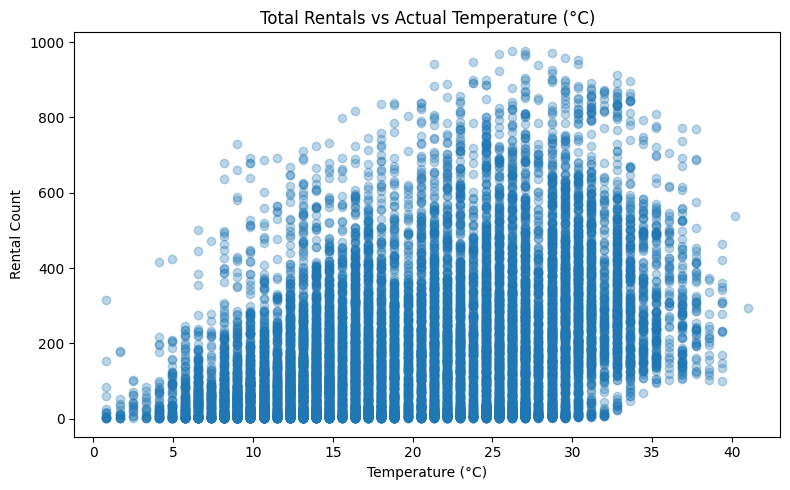

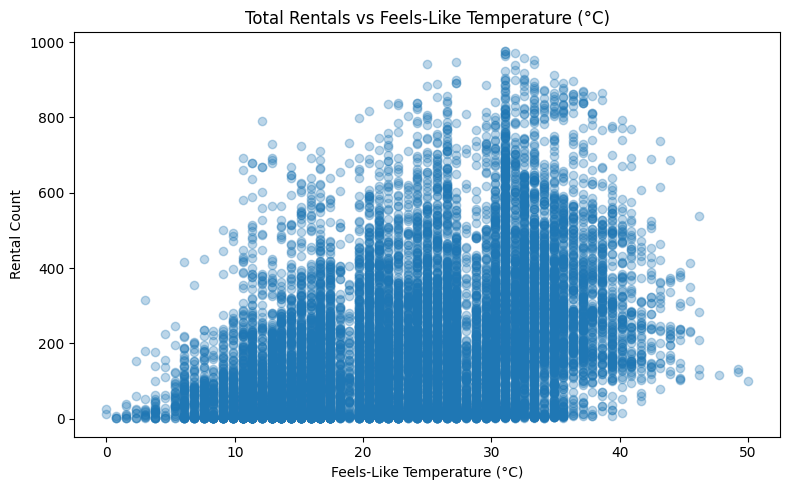

In [ ]:

df['temp_c'] = df['temp'] * 41
df['atemp_c'] = df['atemp'] * 50

# Plot 1: Rentals vs. Actual Temperature
plt.figure(figsize=(8, 5))
plt.scatter(df['temp_c'], df['cnt'], alpha=0.3)
plt.title("Total Rentals vs Actual Temperature (°C)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rental Count")
plt.tight_layout()
plt.show()

# Plot 2: Rentals vs. Feels-Like Temperature
plt.figure(figsize=(8, 5))
plt.scatter(df['atemp_c'], df['cnt'], alpha=0.3)
plt.title("Total Rentals vs Feels-Like Temperature (°C)")
plt.xlabel("Feels-Like Temperature (°C)")
plt.ylabel("Rental Count")
plt.tight_layout()
plt.show()


